## Load Necessary Tools
Vizualization References
[Pandas](http://pandas.pydata.org/pandas-docs/stable/visualization.html),
[Seaborn](https://seaborn.pydata.org/)

In [1]:
# Redshift Engine
from sqlalchemy import create_engine
from pandas import read_sql_query as qry
# Data Sci 
import pandas as pd
import numpy as np
from sklearn import metrics # roc_curve, roc_auc_score, auc, average_precision_score
from sklearn.model_selection import train_test_split
import tensorflow as tf
# Viz
%matplotlib inline
from matplotlib import pyplot as plt
from pandas.tools.plotting import scatter_matrix

## Connect to Redshift

In [2]:
db='<database>'
host='<redshift-host>'
user='<username>'
psswd='<password>'
conStr='postgresql://'+user+':'+psswd+'@'+host+':5439/'+db
con = create_engine(conStr)

## Import Data

In [16]:
# Get List of Features
"""
f = qry(" select * from <schema>.<churn_table> \
            WHERE current_state='Active Paid' \
              AND latest_active_period > 29 \
              AND current_rc_payer = 0 \
              AND pmt1_aftr_as_on IS NOT NULL \
              LIMIT 1",con)
"""

In [18]:
# avg_rebuf_ratio_all {1st_, lst_}{7,14,21,30,60,90}days
# bck_lin_dur_{{1,2,3}m},all}: quintile of linear hours in time period
# device_max:  most freq used device
#f.columns[0:99]

In [53]:
# Big4 Dates
rumble = ['2015-01-25','2016-01-24','2017-01-29']
slam = ['2015-08-23','2016-08-21','2017-08-20']
survivor = ['2015-11-22','2016-11-20','2017-11-19']
mania = ['2015-03-29','2016-04-03','2017-04-02']

# Query!
df = qry("SELECT \
              as_on_dt, \
              cust_guid, \
              CASE \
                WHEN ram_country = 'us' THEN 1 \
                ELSE -1 \
                END AS domestic, \
              num_vol_losses, \
              pmt_pct_days_paid, \
              pct_ppv1, \
              num_invol_fail, \
              vod_lst_30days, \
              nxt_view_ep_lst_90days, \
              CASE \
                WHEN no_view_90days_flag = 0 THEN -1 \
                ELSE no_view_90days_flag \
                END AS no_view_90days_flag, \
            CASE \
                WHEN (as_on_dt BETWEEN '" +rumble[0]+ "'::date AND '"+rumble[0]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '" +rumble[1]+ "'::date AND '"+rumble[1]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '" +rumble[2]+ "'::date AND '"+rumble[2]+"'::date + '1 month'::interval) \
                THEN 1 \
                ELSE -1 \
                END AS rumble30, \
            CASE \
                WHEN (as_on_dt BETWEEN '" +slam[0]+ "'::date AND '"+slam[0]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '" +slam[1]+ "'::date AND '"+slam[1]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '" +slam[2]+ "'::date AND '"+slam[2]+"'::date + '1 month'::interval) \
                THEN 1 \
                ELSE -1 \
                END AS slam30, \
            CASE \
                WHEN (as_on_dt BETWEEN '"+survivor[0]+"'::date AND '"+survivor[0]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '"+survivor[1]+"'::date AND '"+survivor[1]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '"+survivor[2]+"'::date AND '"+survivor[2]+"'::date + '1 month'::interval) \
                THEN 1 \
                ELSE -1 \
                END AS survivor30, \
            CASE \
                WHEN (as_on_dt BETWEEN '"+mania[0]+"'::date AND '"+mania[0]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '"+mania[1]+"'::date AND '"+mania[1]+"'::date + '1 month'::interval) \
                  OR (as_on_dt BETWEEN '"+mania[2]+"'::date AND '"+mania[2]+"'::date + '1 month'::interval) \
                THEN 1 \
                ELSE -1 \
                END AS mania30, \
              CASE WHEN date_part('month', as_on_dt::date) =  1 THEN 1 ELSE -1 END AS Jan, \
              CASE WHEN date_part('month', as_on_dt::date) =  2 THEN 1 ELSE -1 END AS Feb, \
              CASE WHEN date_part('month', as_on_dt::date) =  3 THEN 1 ELSE -1 END AS Mar, \
              CASE WHEN date_part('month', as_on_dt::date) =  4 THEN 1 ELSE -1 END AS Apr, \
              CASE WHEN date_part('month', as_on_dt::date) =  5 THEN 1 ELSE -1 END AS May, \
              CASE WHEN date_part('month', as_on_dt::date) =  6 THEN 1 ELSE -1 END AS Jun, \
              CASE WHEN date_part('month', as_on_dt::date) =  7 THEN 1 ELSE -1 END AS Jul, \
              CASE WHEN date_part('month', as_on_dt::date) =  8 THEN 1 ELSE -1 END AS Aug, \
              CASE WHEN date_part('month', as_on_dt::date) =  9 THEN 1 ELSE -1 END AS Sep, \
              CASE WHEN date_part('month', as_on_dt::date) = 10 THEN 1 ELSE -1 END AS Oct, \
              CASE WHEN date_part('month', as_on_dt::date) = 11 THEN 1 ELSE -1 END AS Nov, \
              CASE WHEN date_part('month', as_on_dt::date) = 12 THEN 1 ELSE -1 END AS Dec, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 1 AND 2 THEN 1 ELSE -1 END AS week01, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 3 AND 4 THEN 1 ELSE -1 END AS week03, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 5 AND 6 THEN 1 ELSE -1 END AS week05, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 7 AND 8 THEN 1 ELSE -1 END AS week07, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 9 AND 10 THEN 1 ELSE -1 END AS week09, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 11 AND 12 THEN 1 ELSE -1 END AS week11, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 13 AND 14 THEN 1 ELSE -1 END AS week13, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 15 AND 16 THEN 1 ELSE -1 END AS week15, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 17 AND 18 THEN 1 ELSE -1 END AS week17, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 19 AND 20 THEN 1 ELSE -1 END AS week19, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 21 AND 22 THEN 1 ELSE -1 END AS week21, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 23 AND 24 THEN 1 ELSE -1 END AS week23, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 25 AND 26 THEN 1 ELSE -1 END AS week25, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 27 AND 28 THEN 1 ELSE -1 END AS week27, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 29 AND 30 THEN 1 ELSE -1 END AS week29, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 31 AND 32 THEN 1 ELSE -1 END AS week31, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 33 AND 34 THEN 1 ELSE -1 END AS week33, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 35 AND 36 THEN 1 ELSE -1 END AS week35, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 37 AND 38 THEN 1 ELSE -1 END AS week37, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 39 AND 40 THEN 1 ELSE -1 END AS week39, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 41 AND 42 THEN 1 ELSE -1 END AS week41, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 43 AND 44 THEN 1 ELSE -1 END AS week43, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 45 AND 46 THEN 1 ELSE -1 END AS week45, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 47 AND 48 THEN 1 ELSE -1 END AS week47, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 49 AND 50 THEN 1 ELSE -1 END AS week49, \
              CASE WHEN date_part('week', as_on_dt::date) BETWEEN 51 AND 52 THEN 1 ELSE -1 END AS week51, \
              CASE \
                WHEN pmt1_aftr_as_on  = 0 THEN 1 \
                WHEN pmt1_aftr_as_on >= 1 THEN 0 \
                ELSE NULL \
                END AS churn \
          FROM <schema>.<churn_table> \
            WHERE current_state='Active Paid' \
              AND latest_active_period > 29 \
              AND current_rc_payer = 0 \
              AND pmt1_aftr_as_on IS NOT NULL \
         ",con)

In [54]:
colnames = df.columns.tolist()
x_cols = colnames[3:-2+1]
y_cols = colnames[-1] 
#
extra_cols = colnames[0:2+1]
extra_info = df[extra_cols]
#
print('Inputs: ', x_cols, '\n')
print('Event: ',y_cols)


Inputs:  ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 'num_invol_fail', 'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag', 'rumble30', 'slam30', 'survivor30', 'mania30', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'week01', 'week03', 'week05', 'week07', 'week09', 'week11', 'week13', 'week15', 'week17', 'week19', 'week21', 'week23', 'week25', 'week27', 'week29', 'week31', 'week33', 'week35', 'week37', 'week39', 'week41', 'week43', 'week45', 'week47', 'week49', 'week51'] 

Event:  churn


## Training, Validation, and Test Splits

In [55]:
# Here I modularize pieces of the code so I can do changes later
#   without having to change everything (output just has to be
#   same data type)

#=========================================================
# Tukey Summaries
def tukey(df):
    colnames = df.columns.tolist()
    tuksum = []
    for col in colnames:
        tuksum.append(np.percentile(df[col],[0,25,50,75,100]))
    return colnames, tuksum
#np.percentile(df['num_vol_losses'],[0,25,50,75,100])

cn = df.columns.tolist()
#np.percentile(df[cn[0]],[0,25,50,75,100])
#df[cn[0]]


def fill_nan(df, x_cols, y_cols):
    # Thus far, all inputs w/ NaNs have 0-fill NaN types, 
    #   so we can zero-fill everything... However, this might
    #   not always be the case.
    #
    df = df.fillna(0)
    
    x_data = np.array( df[x_cols], dtype=np.float32)
    #x_data=df[x_cols].astype(float)
    #
    y_data = np.array([df[y_cols]], dtype=np.float32).T
    #y_data=df[x_cols].astype(float)

    return [x_data, y_data]

# Half-Z Normalization
def halfz(xtrain, xval, xtest):
    # vec can be np.array or pd.DataFrame
    mmm = xtrain.mean()
    sss = xtrain.std()
    return {'loc': mmm, 'scale': sss,
      'train': 0.5*(xtrain - mmm)/sss,
      'val': 0.5*(xval - mmm)/sss,
      'test': 0.5*(xtest - mmm)/sss}

#========================================================
def fn01(xtrain, xval, xtest):
    # vec should be 1D np.array or pd.DataFrame
    mn = xtrain.min()
    mx = xtrain.max()
    return {'mn':mn, 'mx':mx,
            'train': (xtrain - mn)/(mx-mn),
            'val':   (xval   - mn)/(mx-mn),
            'test':  (xtest  - mn)/(mx-mn)}


#========================================================
def fn11(xtrain, xval, xtest):
    # vec should be 1D np.array or pd.DataFrame
    mn = xtrain.min()
    mx = xtrain.max()
    return {'mn':mn, 'mx':mx,
            'train': (2*xtrain - (mx+mn))/(mx-mn),
            'val':   (2*xval   - (mx+mn))/(mx-mn),
            'test':  (2*xtest  - (mx+mn))/(mx-mn)}
    
    return(xtrain, xvalid, xtest, mn_list, mx_list)


#========================================================
def fnn(xtrain, xvalid, xtest):
    colnames = xtrain.columns.tolist()
    mn_list = xtrain.min()
    mx_list = xtrain.max()
    
    for col in colnames:
        mn = mn_list[col]
        mx = mx_list[col]
        xtrain[col] = (2*xtrain[col] - (mx+mn))/(mx-mn)
        xvalid[col] = (2*xvalid[col] - (mx+mn))/(mx-mn)
        xtest[col]  = (2*xtest[col]  - (mx+mn))/(mx-mn)
        
    return(xtrain, xvalid, xtest, mn_list, mx_list)


#=========================================================
def split_data(x_data, y_data, split1=0.5, split2=0.5):
    # Default Training-Validation-Test: 50%, 25%, 25%
    #   -- Training          = 1.0 - split1
    #   -- Validation + Test = split1
    #   -- Validation        = split1*(1.0 - split2)
    #   -- Test              = split1*split2
    x_train, x_vt, y_train, y_vt = train_test_split(x_data, y_data, 
                                            test_size = split1, random_state=42)
    x_valid, x_test, y_valid, y_test = train_test_split(x_vt, y_vt, 
                                            test_size = split2, random_state=31)
    return([x_train,x_valid,x_test], [y_train,y_valid,y_test])


#=========================================================
def raw_churn_data(df, x_cols, y_cols):
    
    # Fill NaNs
    x_data, y_data = fill_nan(df, x_cols, y_cols)
    
    # Data Shape
    n_data     = x_data.shape[0]
    n_features = x_data.shape[1]
    n_classes  = y_data.shape[1]
    features = x_cols
    event = y_cols
    
    # Splits
    x_splits, y_splits = split_data(x_data, y_data)
    
    # Output
    return(
        {
            'x_train': x_splits[0], 'x_valid': x_splits[1], 'x_test': x_splits[2],
            'y_train': y_splits[0], 'y_valid': y_splits[1], 'y_test': y_splits[2],
            'n_data': n_data, 'n_features': n_features, 'n_classes': n_classes,
            'features': features, 'event': event
        }
    )

def churn_transform(raw_data):
    # ew, ... my cooler code up there made it so it's even messier down here...
    x_train = raw_data['x_train']
    x_valid = raw_data['x_valid']
    x_test  = raw_data['x_test']
    y_train = raw_data['y_train']
    y_valid = raw_data['y_valid']
    y_test = raw_data['y_test']
    n_data = raw_data['n_data']
    n_features = raw_data['n_features']
    n_classes = raw_data['n_classes']
    
    # Logarithms
    x_train[:,0], x_valid[:,0], x_test[:,0] = \
        np.log(x_train[:,0]+1), np.log(x_valid[:,0]+1), np.log(x_test[:,0]+1)
    x_train[:,1], x_valid[:,1], x_test[:,1] = \
        np.log(x_train[:,1]+1), np.log(x_valid[:,1]+1), np.log(x_test[:,1]+1)
    x_train[:,2], x_valid[:,2], x_test[:,2] = \
        np.log(x_train[:,2]+1), np.log(x_valid[:,2]+1), np.log(x_test[:,2]+1)
    x_train[:,3], x_valid[:,3], x_test[:,3] = \
        np.log(x_train[:,3]+1), np.log(x_valid[:,3]+1), np.log(x_test[:,3]+1)
    x_train[:,4], x_valid[:,4], x_test[:,4] = \
        np.log(x_train[:,4]+1), np.log(x_valid[:,4]+1), np.log(x_test[:,4]+1)
    x_train[:,5], x_valid[:,5], x_test[:,5] = \
        np.log(x_train[:,5]+1), np.log(x_valid[:,5]+1), np.log(x_test[:,5]+1)
        
    # Feature Normalization
    f0 = fn11(x_train[:,0],x_valid[:,0],x_test[:,0])
    f1 = fn11(x_train[:,1],x_valid[:,1],x_test[:,1])
    f2 = fn11(x_train[:,2],x_valid[:,2],x_test[:,2])
    f3 = fn11(x_train[:,3],x_valid[:,3],x_test[:,3])
    f4 = fn11(x_train[:,4],x_valid[:,4],x_test[:,4])
    f5 = fn11(x_train[:,5],x_valid[:,5],x_test[:,5])
    
    x_train[:,0],x_valid[:,0],x_test[:,0] = f0['train'], f0['val'], f0['test']
    x_train[:,1],x_valid[:,1],x_test[:,1] = f1['train'], f1['val'], f1['test']
    x_train[:,2],x_valid[:,2],x_test[:,2] = f2['train'], f2['val'], f2['test']
    x_train[:,3],x_valid[:,3],x_test[:,3] = f3['train'], f3['val'], f3['test']
    x_train[:,4],x_valid[:,4],x_test[:,4] = f4['train'], f4['val'], f4['test']
    x_train[:,5],x_valid[:,5],x_test[:,5] = f5['train'], f5['val'], f5['test']  
        
    return(x_train, y_train, x_valid, y_valid, x_test, y_test)


    

In [56]:
#  Sheet "Floor-Cap" discusses clipping range and missing vals

In [57]:
raw_data = raw_churn_data(df,x_cols,y_cols)
n_classes = raw_data['n_classes']
print('Training:    (n_instances, n_features) = ', raw_data['x_train'].shape)
print('Validation:  (n_instances, n_features) = ', raw_data['x_valid'].shape)
print('Test:        (n_instances, n_features) = ', raw_data['x_test'].shape)

print(' ')

print('Features:', raw_data['features'])
print(' ')
print('Event:', raw_data['event'])

Training:    (n_instances, n_features) =  (297101, 49)
Validation:  (n_instances, n_features) =  (148550, 49)
Test:        (n_instances, n_features) =  (148551, 49)
 
Features: ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 'num_invol_fail', 'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag', 'rumble30', 'slam30', 'survivor30', 'mania30', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec', 'week01', 'week03', 'week05', 'week07', 'week09', 'week11', 'week13', 'week15', 'week17', 'week19', 'week21', 'week23', 'week25', 'week27', 'week29', 'week31', 'week33', 'week35', 'week37', 'week39', 'week41', 'week43', 'week45', 'week47', 'week49', 'week51']
 
Event: churn


In [58]:
x_train, y_train, x_valid, y_valid, x_test, y_test = churn_transform(raw_data)

In [59]:
print('Min:', x_train[:,5].min(), 'Mean:', x_train[:,5].mean(), 'Max:', x_train[:,5].max())

Min: -1.0 Mean: -0.699697 Max: 1.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x12f97a470>]], dtype=object)

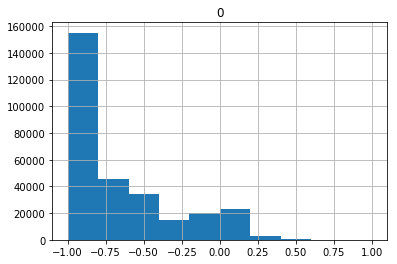

In [60]:
pd.DataFrame(x_train[:,5]).hist()

## Check Point
The data has been extracted from Redshift, split 50-25-25 into the train-validate-test subsets, and properly transformed and normalized to take full advantage of machine learning algorithms. It is now time to construct the logistic regression architecture in TensorFlow's neural network representation.

#### WTF?!?!?!
Might I have a class imbalance problem?!
https://aqibsaeed.github.io/2016-08-10-logistic-regression-tf/

#### Some Helpful TF Pages
http://learningtensorflow.com/index.html

In [61]:
def fully_conn(x_tensor, n_outputs, activation=None, keep_prob=None, seed=None):
    """
    """    
    
    #=======================================
    # Layer Parameters
    #=======================================
    #   -- y = x*W + b
    #   -- if x is (n_instances x 8), then W should be (8x1) 
    #        s.t. xW is (n_instances x 1)
    n_features = x_tensor.get_shape()[1].value
    
    weight = tf.Variable(
        tf.truncated_normal(
            (n_features,n_outputs),
            mean=0,
            stddev=np.sqrt(2.0/n_features),
            dtype=tf.float32,
            seed=seed))
    
    bias = tf.Variable(
            tf.zeros(
            n_outputs,
            dtype=tf.float32),
        name="bias")
        
    #=======================================
    # "Linear Regression" Layer
    #=======================================
    fc_layer = tf.add(tf.matmul(x_tensor, weight), bias)
    
    #=======================================
    # Activation Function
    #=======================================
    # Choose 'sigmoid' for Logistic Regression
    if activation=='relu':
        fc_layer = tf.nn.relu(fc_layer)
    elif activation=='sigmoid':
        fc_layer = tf.nn.sigmoid(fc_layer)
    elif activation=='tanh':
        fc_layer = tf.nn.tanh(fc_layer)
    elif activation=='softplus':
        fc_layer = tf.nn.softplus(fc_layer)
        
    #=======================================
    # Post-Layer Drop Out Option
    #=======================================
    if keep_prob != None:
        fc_layer = tf.nn.dropout(fc_layer, keep_prob)
       
    return fc_layer

In [63]:

# Feature Sets
# Note on B4:  I formerly defined the B4 vars as the answer to the
#   question, "Is this B4 event w/in next 30 days?"  However, I realized
#   that's a better "winback question."  The relevant "churn question" is,
#   "Was this B4 event w/in the past 30 days?"
exl    = colnames[3:9+1]
xx_exl = [0,1,2,3,4,5,6]

b4 = colnames[10:13+1]
xx_b4 = [7,8,9,10]

months = colnames[14:25+1]
xx_months = [11,12,13,14,15,16,17,18,19,20,21,22]

"""
weeks = colnames[26:77+1]
xx_weeks = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
           36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48,
           49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61,
           62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74]
"""
fortnights = colnames[26:51+1]
xx_fortnights = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 
                 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48]

exl_b4 = exl + b4
xx_exl_b4 = xx_exl + xx_b4

exl_months = exl + months
xx_exl_months = xx_exl + xx_months

"""
exl_weeks = exl + weeks
xx_exl_weeks = xx_exl + xx_weeks
"""
exl_fortnights = exl+fortnights
xx_exl_fortnights = xx_exl + xx_fortnights

exl_b4_months = exl + b4 + months
xx_az = xx_exl + xx_b4 + xx_months
#EXL_B4     = colnames[3:13+1]
#EXL_B4_months = colnames[3:25+1]

#singles
EXL_nvl    = [colnames[3]]
EXL_ppd    = [colnames[4]]
EXL_ppv    = [colnames[5]]
EXL_nif    = [colnames[6]]
EXL_nv90d  = [colnames[7]]
EXL_vod30d = [colnames[8]]
EXL_nxt90d = [colnames[9]]
ppd_and_ppv = colnames[4:5+1]
ppd_nvl = [colnames[3],colnames[4]]
ppv_nvl = [colnames[3],colnames[5]]
ppd_ppv_nvl = [colnames[3],colnames[4],colnames[5]]
top3_B4 = ppd_ppv_nvl+b4
#rando = [colnames[5]]


In [94]:
#==============================================
# Choose x_cols
#==============================================
x_cols = exl_months
xx_cols = xx_exl_months

xx_train = x_train[:,xx_cols]
xx_valid = x_valid[:,xx_cols]
xx_test = x_test[:,xx_cols]
n_features = xx_train.shape[1]

#
extra_cols = colnames[0:1+1]
extra_info = df[extra_cols]
#
print('Chosen Inputs: ', x_cols, '\n')
print('Chosen Indices: ', xx_cols,'\n')
print('Event: ',y_cols)
print('X Shape: ', xx_train.shape)


Chosen Inputs:  ['num_vol_losses', 'pmt_pct_days_paid', 'pct_ppv1', 'num_invol_fail', 'vod_lst_30days', 'nxt_view_ep_lst_90days', 'no_view_90days_flag', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] 

Chosen Indices:  [0, 1, 2, 3, 4, 5, 6, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22] 

Event:  churn
X Shape:  (297101, 19)


In [116]:
# Sometimes necessary:
# sess.close()

#-----------------------------------------------------
# Session Parameters
#-----------------------------------------------------
learning_rate = 0.05
epochs = 7
batch_size=250
display_step = 1


# Just in case...
tf.reset_default_graph()

#-----------------------------------------------------
# Input Data Placeholders
#-----------------------------------------------------
#  -- None: 
#     [None, n_features] and [None, n_classes] denotes that
#     we are not specifying how many instances will be used
#     for any given training session or data batch.
####
## need to set x_feed to (None,n_features) after experimentation
#x_feed = tf.placeholder(shape=(None,1), dtype=tf.float32)
x_feed = tf.placeholder(shape=(None,n_features), dtype=tf.float32, name="x_feed")
y_feed = tf.placeholder(shape=(None,n_classes), dtype=tf.float32, name="y_feed")


#-----------------------------------------------------
# Construct model
#-----------------------------------------------------
#  -- to construct a simple logistic regression, 
#     construct a simple linear regression and  
#     compute its sigmoid
#  -- to construct a multiple logistic regression,
#     construct a multiple linear regression and
#     compute its softmax
#
#  Note: SimpLogReg->tf.multiply, MultLogReg->tf.matmul
#
#linReg = tf.add(tf.matmul(x_feed, w), b)
#y_model = tf.nn.sigmoid(linReg)
#y_model = fully_conn(x_feed, n_classes, activation='sigmoid', keep_prob=None, seed=2)
y_model = x_feed
y_model = fully_conn(y_model, 19, activation='sigmoid', keep_prob=None, seed=2)
#y_model = fully_conn(y_model, 3, activation='sigmoid', keep_prob=None, seed=3)
y_model = fully_conn(y_model, n_classes, activation='sigmoid', keep_prob=None, seed=5)


#-----------------------------------------------------
# Choose a Learning Method:  Loss Fcn & Optimizer
#-----------------------------------------------------
# Optimizers: tf.train.
#               AdamOptimizer, GradientDescentOptimizer
loss = tf.reduce_mean(tf.square(y_model - y_feed), name="loss")
#loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits=y_model,labels=y_feed))
#optimizer = tf.train.AdamOptimizer(learning_rate, name="opt")
optimizer = tf.train.AdadeltaOptimizer(learning_rate, name="opt")
train = optimizer.minimize(loss)


# Other Optmization/Loss Options (future exploration)
# Cross Entropy w/ Gradient Descent
# If I bin all my numerical data, I can use classification techniques...
#cost_ce = tf.reduce_mean(-tf.reduce_sum(y*tf.log(py), reduction_indices=1))
#cost_ce = tf.reduce_mean(-tf.reduce_sum(y*tf.log(py)))
#cost_ce = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(py,y),reduction_indices=1)
#opt_gd_ce = tf.train.GradientDescentOptimizer(learning_rate).minimize(cost_ce)
#loss = tf.nn.l2_loss(py - y, name="l2_cost")
# Adam
#opt_adam_ce = tf.train.AdamOptimizer(learning_rate).minimize(cost_ce)
#opt_adam_l2 = tf.train.AdamOptimizer(learning_rate).minimize(cost_l2)



In [117]:
#-----------------------------------------------------
# Initialize TF Variables
#-----------------------------------------------------
init = tf.global_variables_initializer()

#-----------------------------------------------------
# Open TF Session
#-----------------------------------------------------
sess = tf.Session()

#-----------------------------------------------------
# Graph Execution / Training
#-----------------------------------------------------
sess.run(init)
param_updates = []
#param_updates = np.empty(shape=[1],dtype=float)

## Execute TensorFlow Session

In [118]:
# in separate cell in case you want to continue training
for i in range(epochs):
    avg_loss = 0.0
    total_batch = int(xx_train.shape[0]/batch_size)
    
    for j in range(total_batch):
        bx = xx_train[i*batch_size:(i+1)*batch_size]
        # Old Way
        #evals = sess.run([train, loss], feed_dict={y_feed: y_train, x_feed: x_train})[1:]
        #avg_loss += evals[2]/total_batch
        # W/ fully_conn
        evals = sess.run([train, loss], feed_dict={y_feed: y_train, x_feed: xx_train})[1]
        avg_loss += evals/total_batch
    
    if i % display_step == 0:
        #_w = evals[0][0,0]  # for simpLogReg
        #_w = evals[0][0,0]  # for multLogReg
        #_b = evals[1][0]
        #_l = evals[2]
        _l = evals
        print('Epoch: ','%04d' % (i+1))#, '  Weight: ','{:.9f}'.format(_w),'  Bias: ','{:.9f}'.format(_b))
        print('    EndLoss: ', '{:.9f}'.format(_l),'  AvgLoss: ', 
              '{:.9f}'.format(avg_loss))
        print(' ')
        param_updates.append(evals)

print('Training Complete!')
#wf=_w
#bf=_b
#print('Final Parameters: ')
#print('    w: ', wf)
#print('    b: ', bf)

#-----------------------------------------------------
# How good did we do?
#-----------------------------------------------------
# !!! Change x_temp -> x_train after experimentation !!!!!!!!!!!
##y_pred = sess.run(y_model, feed_dict = {x_feed: x_tempval})
y_pred  = sess.run(y_model, feed_dict = {x_feed: xx_valid})
y_class = np.array(y_pred > 0.5, dtype=np.float32)



Epoch:  0001
    EndLoss:  0.089076035   AvgLoss:  0.126376461
 


## Scores

In [114]:
#-----------------------------------------------------
# Close TF Session
#-----------------------------------------------------
#sess.close()

# fpr, tpr, threshold = metrics.roc_curve(y_valid, y_pred, pos_label=1)
# auc = metrics.auc(fpr,tpr)

y_class = np.array(y_pred > 0.5,dtype=np.float32)

print('AUROC (AUC): ',round(100*metrics.roc_auc_score(y_valid, y_pred),1))
# Accuracy: Is this model a good "shot caller"?
#   -- must binarize y_pred, (e.g., what threshold is roc_auc_score using?)
#  -- y_class = ...
print('Accuracy:    ',round(100*metrics.accuracy_score(y_valid, y_class, normalize=True),1))

# Precision: 
#  -- precision is the ability of the classifier not to label a negative sample as positive
#  -- precision = tp / (tp+fp)
print('Precision:   ',round(100*metrics.precision_score(y_valid, y_class),1))

# Recall: 
#  -- recall is the ability of the classifier to find all the positive samples
print('Recall:      ', round(100*metrics.recall_score(y_valid, y_class),1))

# Average Precision: Area under the Precision-Recall curve
#  -- precision = tp / (tp+fp)
#  -- recall = tp / (tp+fn)
print('AUPRC:       ',round(100*metrics.average_precision_score(y_valid, y_pred),1))

# F1 Score
#  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
#  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
#  -- y_class = ...
print('F1 Score:    ',round(100*metrics.f1_score(y_valid, y_class),1))

# R2 Score
#  -- must binarize y_pred (e.g., what threshold is roc_auc_score using?)
#  -- f1 = harmonic_mean(precision, recall) = 2pr/(p+r)
#  -- y_class = ...
print('R2 Score:    ',round(100*metrics.r2_score(y_valid, y_pred),1))
print('MnAbsErr:    ',round(100*metrics.mean_absolute_error(y_valid, y_pred),1))
print('MnSqErr:     ',round(100*metrics.mean_squared_error(y_valid, y_pred),1))
print('MedAbsErr:   ',round(100*metrics.median_absolute_error(y_valid, y_pred),1))

AUROC (AUC):  75.8
Accuracy:     93.3
Precision:    65.9
Recall:       1.2
AUPRC:        24.4
F1 Score:     2.3
R2 Score:     8.9
MnAbsErr:     11.9
MnSqErr:      5.8
MedAbsErr:    4.9


In [115]:
#-----------------------------------------------------
# Close TF Session
#-----------------------------------------------------
sess.close()


In [342]:
pd.DataFrame(x_train[4,:]).max()

0   -0.456482
dtype: float32

In [59]:
print('Churners')
print('Customers who churn in 1 month: ','{:.2f}'.format((100*sum(y_train==1)/y_train.shape[0])[0]),'% of the training set')
print('Customers who churn in 1 month: ','{:.2f}'.format((100*sum(y_valid==1)/y_valid.shape[0])[0]),'% of the validation set')
print('Customers who churn in 1 month: ','{:.2f}'.format((100*sum(y_test==1)/y_test.shape[0])[0]),'% of the test set')
print('')
print('The Retained')
print('Customers who are retained: ','{:.2f}'.format((100*sum(y_train==0)/y_train.shape[0])[0]),'% of the training set')
print('Customers who are retained: ','{:.2f}'.format((100*sum(y_valid==0)/y_valid.shape[0])[0]),'% of the validation set')
print('Customers who are retained: ','{:.2f}'.format((100*sum(y_test==0)/y_test.shape[0])[0]),'% of the test set')
print('')
print('Model Accuracy','{:.2f}'.format(100*(sum(y_valid == y_class)/y_valid.shape[0])[0]))

Churners
Customers who churn in 1 month:  6.83 % of the training set
Customers who churn in 1 month:  6.79 % of the validation set
Customers who churn in 1 month:  6.79 % of the test set

The Retained
Customers who are retained:  93.17 % of the training set
Customers who are retained:  93.21 % of the validation set
Customers who are retained:  93.21 % of the test set

Model Accuracy 93.21


==============================================
# Experimental Code
===============================================
Try out stuff later on....

In [32]:
#===============================================================
## NOTE: 2017-03-23:  Convert later....
#===============================================================
######### Might actually be able to keep data frames...
### e.g., see Data Shape portion above w/
###     x_data=df[x_cols].astype(float)
## Causes a lot of warnings:  aa = fnndf(x_train,x_valid,x_test)
#######
def fnndf(xtrain,xvalid,xtest):
    colnames = xtrain.columns.tolist()
    mn_list = xtrain.min()
    mx_list = xtrain.max()
    
    for col in colnames:
        mn = mn_list[col]
        mx = mx_list[col]
        xtrain[col] = (2*xtrain[col] - (mx+mn))/(mx-mn)
        xvalid[col] = (2*xvalid[col] - (mx+mn))/(mx-mn)
        xtest[col]  = (2*xtest[col]  - (mx+mn))/(mx-mn)
        
    return {'mn':mn_list, 'mx':mx_list,
            'train': xtrain,
            'val':   xvalid,
            'test':  xtest}



TensorShape([Dimension(None), Dimension(1)])

===================================================
# OLD CODE
## Do Not Run
===================================================

In [ ]:

#######################################################
# OLD CODE
######################################################


#-----------------------------------------------------
# Graph Execution
#-----------------------------------------------------
param_updates = np.empty(shape=[1],dtype=float)
with tf.Session() as sess:
    sess.run(init)

    #-------------------------------------------------
    # TRAINING 
    #-------------------------------------------------
    # Cycle over Epochs
    for epoch in range(epochs):
        avg_cost = 0.
        total_batch = int(x_train.shape[0]/batch_size)
        
        # Cycle over Batches
        for i in range(total_batch):
            # Get Batch
            bx_train = np.array(x_train[i*batch_size:(i+1)*batch_size], dtype='float32')
            by_train = np.array(y_train[i*batch_size:(i+1)*batch_size], dtype='float32')

            # Fit to Batch
            sess.run(train, feed_dict={x: bx_train, y: by_train})
            #sess.run(opt_gd_ce, feed_dict={x: batch_xs, y: batch_ys})
            
            # Record the Cost
            ccc = sess.run(loss, feed_dict={x: bx_train, y: by_train})

            # Compute average loss
            avg_cost += ccc / total_batch
        # endFor: Batches #########
        param_updates = np.append(param_updates, avg_cost)

        # Display logs per epoch step
        if (epoch+1) % display_step == 0:
            print("Epoch:", '%04d' % (epoch+1), "cost=", "{:.9f}".format(avg_cost))
    # endFor: Epochs ##########
    
    print("Optimization Finished!")

    #-------------------------------------------------
    # Test model
    #-------------------------------------------------
    # tf.argmax:  https://www.tensorflow.org/api_docs/python/tf/argmax
    #   --  Returns the index with the largest value across axes of a tensor.
    # argmax(py, 1) gives model's most likely label
    # argmax(y, 1) is the actual label
    py = sess.run(py , feed_dict = {x: x_test})
    correct_prediction = tf.equal(tf.argmax(py, 1), tf.argmax(y, 1))
    accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
    #print("Accuracy:", accuracy.eval({x: x_valid[:10000], y: y_valid[:10000]}))
    print("Accuracy:", sess.run(accuracy, feed_dict = {x: x_valid[:10000], y: y_valid[:10000]}))